# Regularized least squares with $L_2$ and $L_1$

We solve inverse problems of the form

$$
\mathbf{d} \approx A\mathbf{m},
$$

where $\mathbf{d}$ is the observed data, $A$ is the forward operator, and $\mathbf{m}$ is the unknown model.

We compare three cases:

1. Unregularized least squares
2. $L_2$ regularization:
   $$
   J(\mathbf{m}) = \frac{1}{2}\|A\mathbf{m}-\mathbf{d}\|_2^2 + \frac{\lambda}{2}\|L\mathbf{m}\|_2^2
   $$
3. $L_1$ regularization:
   $$
   J(\mathbf{m}) = \frac{1}{2}\|A\mathbf{m}-\mathbf{d}\|_2^2 + \lambda \|L\mathbf{m}\|_1
   $$

The $L_2$ problem is quadratic and can be solved directly with conjugate gradients.

The $L_1$ problem is not differentiable at zero, so we use an outer Iteratively Reweighted Least Squares (IRLS) scheme. Each IRLS step produces a weighted quadratic problem, and that inner problem is solved with conjugate gradients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, cg

np.random.seed(7)

## Build a synthetic inverse problem

We use a simple 1D model with sharp jumps, then create data by applying a smoothing operator and adding noise.

This is a good example because:
- the true model is blocky,
- the data are blurred and noisy,
- regularization becomes necessary.

In [2]:
# ------------------------------------------------------------
# True model: piecewise constant
# ------------------------------------------------------------
n_model = 120
x = np.linspace(0, 1, n_model)

m_true = np.zeros(n_model)
m_true[(x >= 0.15) & (x < 0.35)] = 1.0
m_true[(x >= 0.50) & (x < 0.70)] = -0.8
m_true[(x >= 0.80) & (x < 0.90)] = 0.6

# ------------------------------------------------------------
# Forward operator A: simple blur matrix
# ------------------------------------------------------------
def gaussian_kernel(size=21, sigma=3.0):
    t = np.arange(size) - size // 2
    g = np.exp(-(t**2) / (2 * sigma**2))
    g /= g.sum()
    return g

kernel = gaussian_kernel(size=21, sigma=3.0)

def convmtx_same(kernel, n):
    """Build a dense convolution matrix with same-size output."""
    k = len(kernel)
    half = k // 2
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            idx = i - j + half
            if 0 <= idx < k:
                A[i, j] = kernel[idx]
    return A

A_mat = convmtx_same(kernel, n_model)

# Synthetic data
d_clean = A_mat @ m_true
noise_level = 0.05
d_obs = d_clean + noise_level * np.random.randn(n_model)

Text(0.5, 0, 'x')

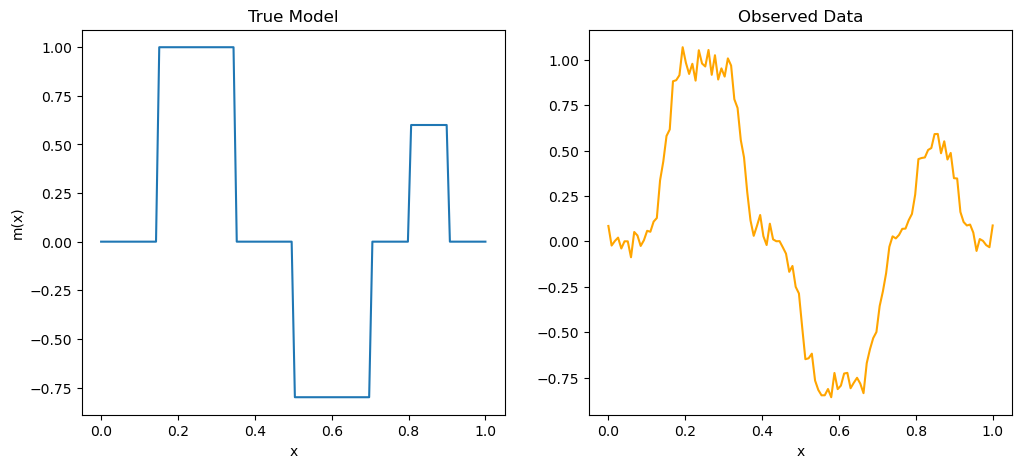

In [3]:
# make a plot with two figures, the model on the size and the data on the right
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(x, m_true, label='True Model')
axs[0].set_title('True Model')
axs[0].set_xlabel('x')
axs[0].set_ylabel('m(x)')

axs[1].plot(x, d_obs, label='Observed Data', color='orange')
axs[1].set_title('Observed Data')
axs[1].set_xlabel('x')         

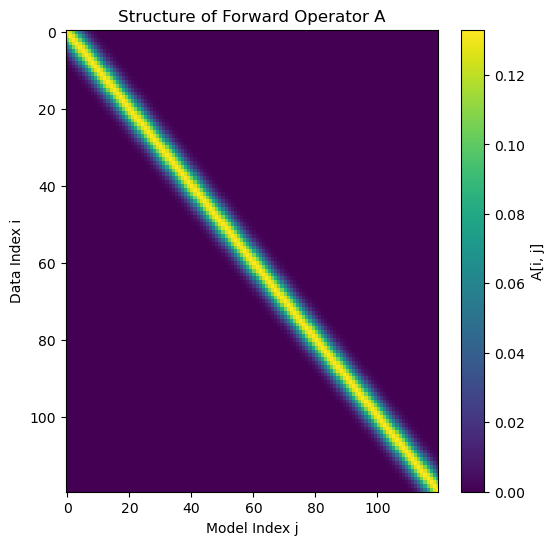

In [4]:
# plot the structure of the matrix A
plt.figure(figsize=(6, 6))
plt.imshow(A_mat, cmap='viridis', aspect='auto')
plt.colorbar(label='A[i, j]')
plt.title('Structure of Forward Operator A')
plt.xlabel('Model Index j')
plt.ylabel('Data Index i')
plt.show()


## Define operators

We write the forward operator $A$ and the regularization operator $L$ in a generic operator style.

This makes the code easy to adapt later if $A$ is not stored explicitly as a matrix.

In [5]:
# ------------------------------------------------------------
# Forward operator A as a LinearOperator
# ------------------------------------------------------------
def make_linear_operator_from_matrix(M):
    m, n = M.shape
    return LinearOperator(
        shape=(m, n),
        matvec=lambda x: M @ x,
        rmatvec=lambda y: M.T @ y,
        dtype=float
    )

A = make_linear_operator_from_matrix(A_mat)

# ------------------------------------------------------------
# First-difference regularization operator L
# (Lm)_i = m_{i+1} - m_i
# ------------------------------------------------------------
def diff1_matvec(m):
    return m[1:] - m[:-1]

def diff1_rmatvec(v):
    out = np.zeros(len(v) + 1)
    out[:-1] -= v
    out[1:]  += v
    return out

L = LinearOperator(
    shape=(n_model - 1, n_model),
    matvec=diff1_matvec,
    rmatvec=diff1_rmatvec,
    dtype=float
)

## Conjugate gradients for $L_2$ regularization

For the cost

$$
J(\mathbf{m}) = \frac{1}{2}\|A\mathbf{m}-\mathbf{d}\|_2^2 + \frac{\lambda}{2}\|L\mathbf{m}\|_2^2,
$$

the normal equations are

$$
(A^T A + \lambda L^T L)\mathbf{m} = A^T \mathbf{d}.
$$

We do not build $A^T A$ explicitly. Instead, we define the action of the operator on a vector:
$$
\mathbf{x} \mapsto A^T(A\mathbf{x}) + \lambda L^T(L\mathbf{x}).
$$

That is enough for conjugate gradients.

In [6]:
def solve_l2_cg(A, L, d, lam, n, tol=1e-8, maxiter=500):
    """Solve (A^T A + lam L^T L) m = A^T d using conjugate gradients."""

    def H_matvec(m):
        return A.rmatvec(A.matvec(m)) + lam * L.rmatvec(L.matvec(m))

    H = LinearOperator(shape=(n, n), matvec=H_matvec, dtype=float)
    b = A.rmatvec(d)

    m, info = cg(H, b, rtol=tol, maxiter=maxiter)
    return m, info

# Unregularized case: equivalent to lam = 0
m_ls, info_ls = solve_l2_cg(A, L, d_obs, lam=0.0, n=n_model)

# L2-regularized case
lam_l2 = 2.0
m_l2, info_l2 = solve_l2_cg(A, L, d_obs, lam=lam_l2, n=n_model)

print("CG info (LS):", info_ls)
print("CG info (L2):", info_l2)

CG info (LS): 500
CG info (L2): 0


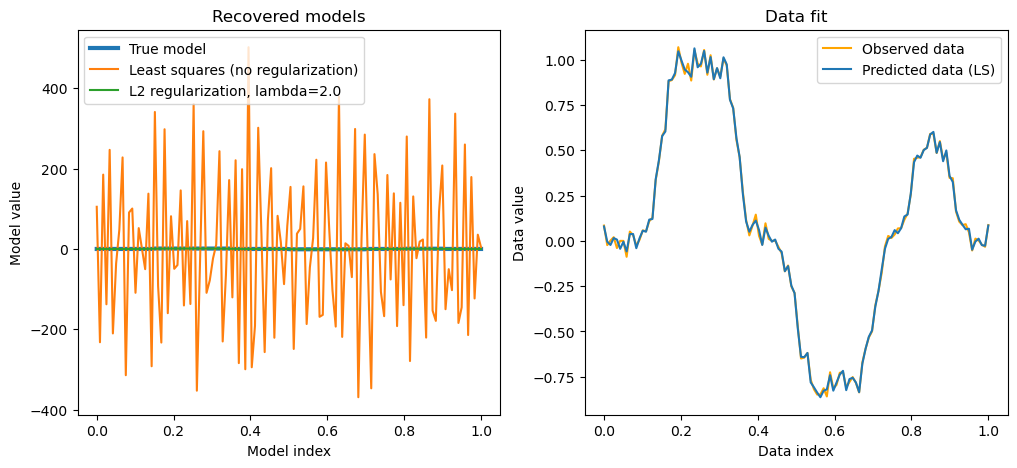

In [7]:
# create two figures side by side, one for the models and one for the data for the unregularized and L2-regularized cases
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, m_true, label="True model", linewidth=3)
plt.plot(x, m_ls, label="Least squares (no regularization)")
plt.plot(x, m_l2, label=f"L2 regularization, lambda={lam_l2}")
plt.xlabel("Model index")
plt.ylabel("Model value")
plt.title("Recovered models")
plt.legend()        
plt.subplot(1, 2, 2)
plt.plot(x, d_obs, label="Observed data", color='orange')
plt.plot(x, A.matvec(m_ls), label="Predicted data (LS)")        
plt.xlabel("Data index")
plt.ylabel("Data value")
plt.title("Data fit")
plt.legend()
plt.show()  

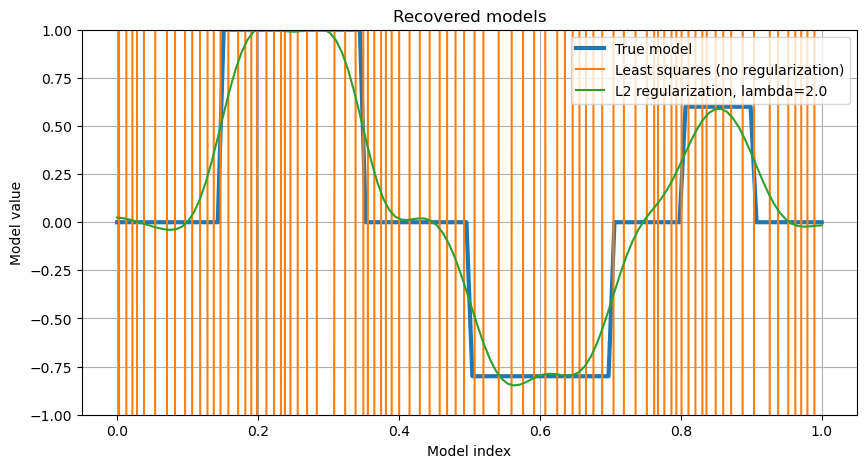

In [8]:
# clip the y-axis of the model plot to better see the differences between the models

plt.figure(figsize=(10, 5))
plt.plot(x, m_true, label="True model", linewidth=3)
plt.plot(x, m_ls, label="Least squares (no regularization)")
plt.plot(x, m_l2, label=f"L2 regularization, lambda={lam_l2}")
plt.ylim(-1.0, 1.0)
plt.xlabel("Model index")
plt.ylabel("Model value")
plt.title("Recovered models")
plt.legend()
plt.grid(True)
plt.show()

## $L_1$ regularization with IRLS + CG

For the cost

$$
J(\mathbf{m}) = \frac{1}{2}\|A\mathbf{m}-\mathbf{d}\|_2^2 + \lambda \|L\mathbf{m}\|_1,
$$

plain conjugate gradients cannot be used directly because the $L_1$ norm is not differentiable at zero.

Instead, IRLS approximates the $L_1$ term by a weighted quadratic form. At iteration $k$, define weights

$$
w_i^{(k)} = \frac{1}{\sqrt{(L\mathbf{m}^{(k)})_i^2 + \epsilon^2}}.
$$

Then solve the quadratic subproblem

$$
(A^T A + \lambda L^T W^{(k)} L)\mathbf{m}^{(k+1)} = A^T\mathbf{d},
$$

where $W^{(k)}$ is diagonal. Each of these subproblems can be solved with CG.

In [14]:
def solve_l1_irls_cg(A, L, d, lam, n, eps=1e-3, n_outer=15, tol_cg=1e-8, maxiter_cg=500):
    """
    Solve
        0.5 ||A m - d||_2^2 + lam ||L m||_1
    using IRLS, with each quadratic subproblem solved by CG.
    """
    def H_matvec(x):
        Ax = A.matvec(x)
        Lx = L.matvec(x)
        WLx = w * Lx
        return A.rmatvec(Ax) + lam * L.rmatvec(WLx)

    m = np.zeros(n)

    history = []

    for k in range(n_outer):
        Lm = L.matvec(m)
        w = 1.0 / np.sqrt(Lm**2 + eps**2)   # diagonal weights

        H = LinearOperator(shape=(n, n), matvec=H_matvec, dtype=float)
        b = A.rmatvec(d)

        m_new, info = cg(H, b, x0=m, rtol=tol_cg, maxiter=maxiter_cg)

        # monitor cost
        data_term = 0.5 * np.linalg.norm(A.matvec(m_new) - d)**2
        reg_term = lam * np.sum(np.abs(L.matvec(m_new)))
        cost = data_term + reg_term
        history.append(cost)

        dm = np.linalg.norm(m_new - m) / (np.linalg.norm(m_new) + 1e-12)
        print(f"IRLS iter {k+1:2d}: cost = {cost:.6f}, rel_change = {dm:.3e}, cg_info = {info}")

        m = m_new

    return m, history

lam_l1 = 0.25
m_l1, hist_l1 = solve_l1_irls_cg(A, L, d_obs, lam=lam_l1, n=n_model, eps=1e-3, n_outer=15)

IRLS iter  1: cost = 7.516140, rel_change = 1.000e+00, cg_info = 0
IRLS iter  2: cost = 1.947634, rel_change = 5.439e-01, cg_info = 0
IRLS iter  3: cost = 1.535494, rel_change = 1.268e-01, cg_info = 0
IRLS iter  4: cost = 1.427372, rel_change = 5.683e-02, cg_info = 0
IRLS iter  5: cost = 1.386993, rel_change = 2.976e-02, cg_info = 0
IRLS iter  6: cost = 1.365827, rel_change = 1.874e-02, cg_info = 0
IRLS iter  7: cost = 1.352454, rel_change = 1.379e-02, cg_info = 0
IRLS iter  8: cost = 1.343165, rel_change = 1.091e-02, cg_info = 0
IRLS iter  9: cost = 1.336317, rel_change = 8.989e-03, cg_info = 0
IRLS iter 10: cost = 1.331057, rel_change = 7.618e-03, cg_info = 0
IRLS iter 11: cost = 1.326884, rel_change = 6.592e-03, cg_info = 0
IRLS iter 12: cost = 1.323484, rel_change = 5.798e-03, cg_info = 0
IRLS iter 13: cost = 1.320660, rel_change = 5.165e-03, cg_info = 0
IRLS iter 14: cost = 1.318278, rel_change = 4.649e-03, cg_info = 0
IRLS iter 15: cost = 1.316242, rel_change = 4.221e-03, cg_info

## Compare the recovered models

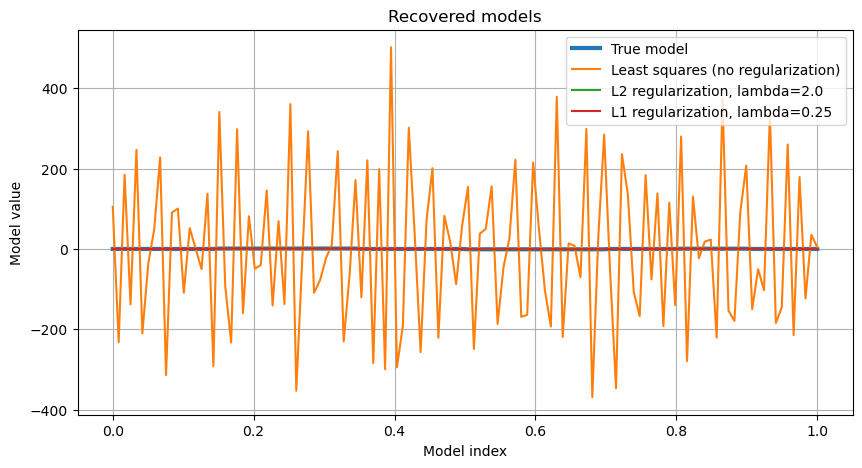

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(x, m_true, label="True model", linewidth=3)
plt.plot(x, m_ls, label="Least squares (no regularization)")
plt.plot(x, m_l2, label=f"L2 regularization, lambda={lam_l2}")
plt.plot(x, m_l1, label=f"L1 regularization, lambda={lam_l1}")
plt.xlabel("Model index")
plt.ylabel("Model value")
plt.title("Recovered models")
plt.legend()
plt.grid(True)
plt.show()

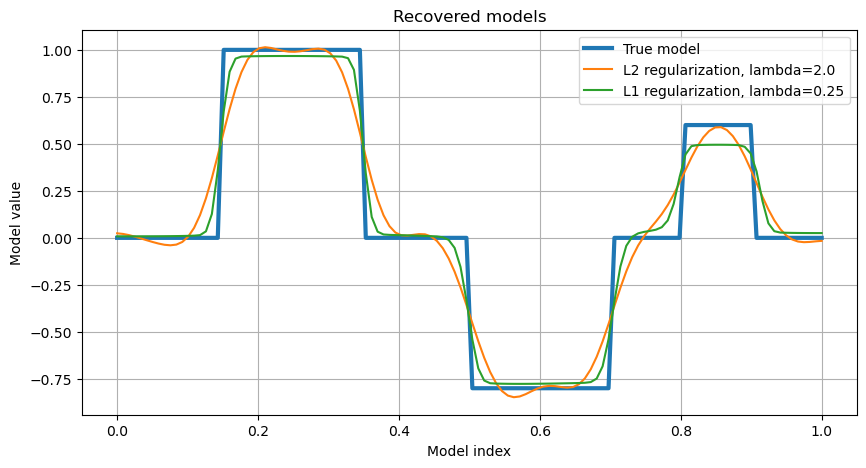

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(x, m_true, label="True model", linewidth=3)
#plt.plot(x, m_ls, label="Least squares (no regularization)")
plt.plot(x, m_l2, label=f"L2 regularization, lambda={lam_l2}")
plt.plot(x, m_l1, label=f"L1 regularization, lambda={lam_l1}")
plt.xlabel("Model index")
plt.ylabel("Model value")
plt.title("Recovered models")
plt.legend()
plt.grid(True)
plt.show()

## Compare the data fit

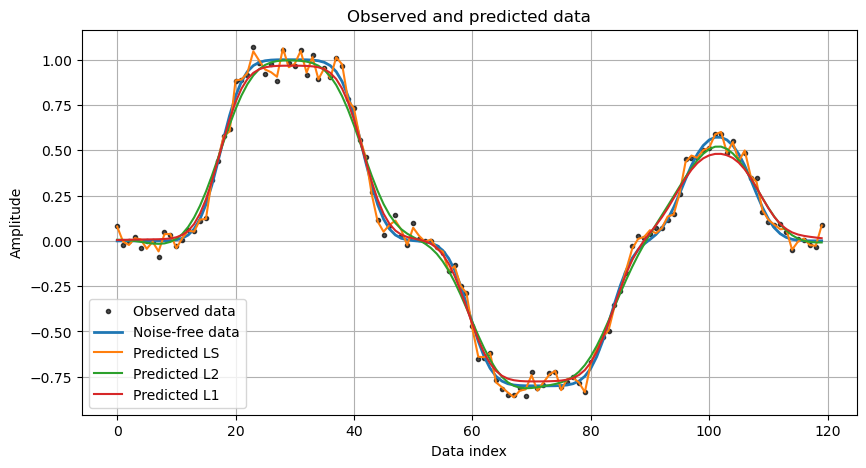

In [17]:
d_ls = A.matvec(m_ls)
d_l2 = A.matvec(m_l2)
d_l1 = A.matvec(m_l1)

plt.figure(figsize=(10, 5))
plt.plot(d_obs, 'k.', label='Observed data', alpha=0.7)
plt.plot(d_clean, label='Noise-free data', linewidth=2)
plt.plot(d_ls, label='Predicted LS')
plt.plot(d_l2, label='Predicted L2')
plt.plot(d_l1, label='Predicted L1')
plt.xlabel("Data index")
plt.ylabel("Amplitude")
plt.title("Observed and predicted data")
plt.legend()
plt.grid(True)
plt.show()

## Inspect the first differences

Since the regularization acts on $L\mathbf{m}$, it is useful to compare the first differences of the recovered models.

- $L_2$ regularization tends to spread changes smoothly.
- $L_1$ regularization tends to concentrate changes into fewer locations, producing sharper edges.

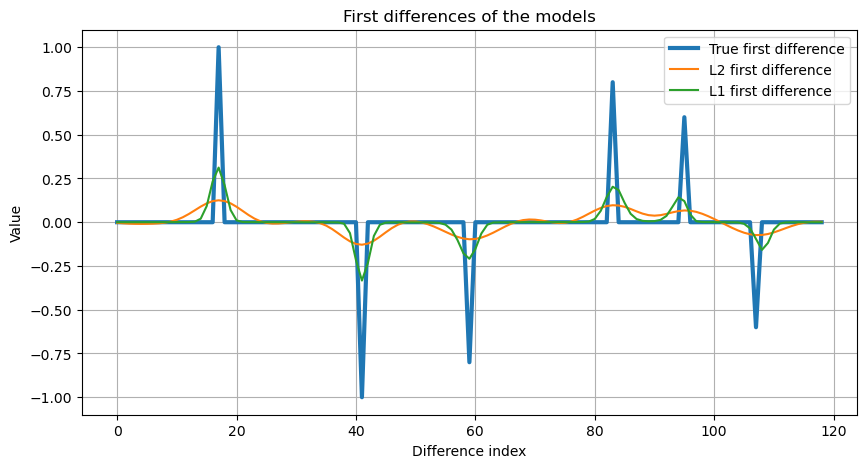

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(L.matvec(m_true), label="True first difference", linewidth=3)
plt.plot(L.matvec(m_l2), label="L2 first difference")
plt.plot(L.matvec(m_l1), label="L1 first difference")
plt.xlabel("Difference index")
plt.ylabel("Value")
plt.title("First differences of the models")
plt.legend()
plt.grid(True)
plt.show()


The important conceptual points in this lecture are:

* **CG** is naturally suited for minimizing a **quadratic** cost
* the $L_2$-regularized problem is quadratic
* the $L_1$-regularized problem is **not smooth**, so plain CG does not apply directly
* but we can still use **CG inside an iterative reweighted least-squares (IRLS)** method

# 1. Main ideas

We already know about linear regression:

$$
\mathbf{d} \approx A\mathbf{m}
$$

where:

* $\mathbf{d}$ = observed data
* $A$ = forward operator or design matrix
* $\mathbf{m}$ = unknown model parameters

The usual least-squares cost is

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2
$$

This works well when the problem is well posed, but in many applications:

* the system is ill-conditioned
* the data are noisy
* there are many models that fit the data almost equally well

So we add a **regularization term**:

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \lambda R(\mathbf{m})
$$

where $\lambda > 0$ controls the tradeoff between data fitting and model simplicity.

---

# 2. $L_2$ regularization

Choose

$$
R(\mathbf{m}) = \frac{1}{2}|L\mathbf{m}|_2^2
$$

Then

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \frac{\lambda}{2}|L\mathbf{m}|_2^2
$$

Common choices:

* $L = I$: penalize large model values
* $L$ = first-difference operator: penalize roughness
* $L$ = second-difference operator: penalize curvature

This gives the normal equations

$$
(A^T A + \lambda L^T L)\mathbf{m} = A^T \mathbf{d}
$$

This is a symmetric positive definite system when $\lambda>0$ and is ideal for **conjugate gradients**.

So $L_2$ regularization is the perfect first example.

---

# 3. $L_1$ regularization

Now choose

$$
R(\mathbf{m}) = |L\mathbf{m}|_1
$$

so the cost becomes

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \lambda |L\mathbf{m}|_1
$$

This is useful because $L_1$ tends to promote:

* sparsity
* blocky or piecewise-constant models
* sharper transitions than $L_2$

But the function $|x|$ is not differentiable at zero, so the whole cost is not a smooth quadratic.

That means:

* **plain CG cannot be applied directly to the full $L_1$ objective**

A workaround is **IRLS**:

$$
|L\mathbf{m}|_1 \approx \frac{1}{2}(L\mathbf{m})^T W (L\mathbf{m}) + \text{constant}
$$

with weights updated from the previous iterate, typically

$$
W_{ii} = \frac{1}{\sqrt{(L\mathbf{m})_i^2 + \epsilon^2}}
$$

Then each IRLS step solves a weighted quadratic problem:

$$
(A^T A + \lambda L^T W L)\mathbf{m} = A^T \mathbf{d}
$$

and **that** can again be solved with CG.

This is an implementation bridge: $L_1$ is harder, but they still get to use CG.

---

# 4. Summary

## Part A: recall least squares

* linear regression as minimizing $|A\mathbf{m}-\mathbf{d}|_2^2$
* gradient:
  $$
  \nabla J = A^T(A\mathbf{m}-\mathbf{d})
  $$

## Part B: we introduce regularization

* motivation instability, noise, non-uniqueness
* define
  $$
  J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \lambda R(\mathbf{m})
  $$

## Part C: Simplest option for regularization - $L_2$

* choose $R(\mathbf{m}) = \frac{1}{2}|L\mathbf{m}|_2^2$
* derive
  $$
  (A^T A + \lambda L^T L)\mathbf{m} = A^T\mathbf{d}
  $$
* solve with CG

## Part D: More specific choice better for sharp models- $L_1$

* choose $R(\mathbf{m}) = |L\mathbf{m}|_1$
* This choice promotes sharpness/sparsity (why?)
* However, CG is not directly applicable (why?)
* Work around: IRLS
* solve each weighted quadratic subproblem with CG


# 5 - Questions


## Why regularization?

Because fitting the data alone is often not enough. Noise and non-uniqueness can produce unstable or unrealistic models.

## What does $L_2$ do?

It discourages large or rough model variations in a smooth way. It usually produces a smoother model.

## What does $L_1$ do?

It promotes sparsity in the quantity being penalized.

* If you penalize $|\mathbf{m}|_1$, you promote sparse model coefficients.
* If you penalize $|L\mathbf{m}|_1$ with $L$ a first-difference operator, you promote sparse jumps, which gives blocky models.

## Why CG for $L_2$?

Because the problem is quadratic and leads to a symmetric positive definite linear system.

## Why not plain CG for $L_1$?

Because the $L_1$ norm is not differentiable at zero, so the cost is not a smooth quadratic.

## Why IRLS?

Because it converts the $L_1$ problem into a sequence of weighted quadratic problems, and each of those can be solved with CG.

---

# 6. A concise derivation 

For $L_2$ regularization:

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \frac{\lambda}{2}|L\mathbf{m}|_2^2
$$

Expand the gradient:

$$
\nabla J(\mathbf{m}) = A^T(A\mathbf{m}-\mathbf{d}) + \lambda L^T L\mathbf{m}
$$

Set gradient to zero:

$$
A^T(A\mathbf{m}-\mathbf{d}) + \lambda L^T L\mathbf{m} = 0
$$

$$
(A^T A + \lambda L^T L)\mathbf{m} = A^T\mathbf{d}
$$

That is the linear system solved by CG.

For $L_1$:

$$
J(\mathbf{m}) = \frac{1}{2}|A\mathbf{m}-\mathbf{d}|_2^2 + \lambda \sum_i |(L\mathbf{m})_i|
$$

The difficulty is the absolute value. IRLS replaces it with a local weighted quadratic approximation.

---

# 7. Take away

> Least squares alone asks: “Which model fits the data best?”
> Regularization adds: “Among all models that fit the data, which one is also simple, smooth, or sparse?”




